### ESQUEMA

1. Cargar y explorar datos: pandas

2. Preprocesado de texto: re, NLTK

3. Vectorización: scikit-learn (TF-IDF / CountVectorizer)

4. Modelo: scikit-learn (Naive Bayes, y luego otros)

5. Evaluación: scikit-learn (metrics, confusion matrix)

6. Mejoras. Desbalance de clases: imbalanced-learn

7. Bonus. Modelo más potente: transformers (BERT fine-tuning)

In [1]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("../data/english_comments.csv")

df.head(3)

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers dont even have cont...,negative
2,i will forever acknowledge this channel with t...,positive


In [13]:
# =======================================================================================================
# VECTORIZACIÓN
# =======================================================================================================

# En este caso se usará TF-IDF (Term Frequency — Inverse Document Frequency):
# TF: cuántas veces aparece la palabra en ese comentario
# IDF: logaritmo inverso de en cuántos documentos aparece
# Penaliza las palabras que aparecen en muchos documentos. A las palabras raras pero significativas como "horrible" o "amazing" les da más peso.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

def vectorization(X_data, y_data):
    # stratify=y es importante: mantiene la proporción de clases en train y test
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
    )

    # Creando vectorizador
    # ignora palabras que aparecen < 3 veces
    # límite de vocabulario
    # unigramas y bigramas
    vectorizer = TfidfVectorizer(min_df=3, max_features=100000, ngram_range=(1,2))

    # Vectorizando los comentarios
    # fit_transform para train porque el modelo aprende de estos comentarios: qué palabras existen, qué posición ocupa cada una en el vector, cuál es el IDF de cada una.
    # transform para test porque sólo necesitamos vectorizarlos (en base a lo aprendido para train). Si usamos fit volveríamos a reconstruir el modelo en base a los datos de test
    X_train_v = vectorizer.fit_transform(X_train)
    X_test_v = vectorizer.transform(X_test)

    # usar fit con datos de entrenamiento ensucia el aprendizaje (data leakage)

    print(f'Total comentarios para entrenamiento: {X_train_v.shape[0]} ({round(X_train_v.shape[0]/len(X_data), 2)*100}% del total)')
    print(f"{round(y_train[y_train == 'positive'].shape[0]/y_train.shape[0], 2)*100}% positives\n{round(y_train[y_train == 'neutral'].shape[0]/y_train.shape[0], 2)*100}% neutros\n{round(y_train[y_train == 'negative'].shape[0]/y_train.shape[0], 2)*100}% negativos\n")
    print(f'Total comentarios para evaluación: {X_test_v.shape[0]} ({round(X_test_v.shape[0]/len(X_data), 2)*100}% del total)')
    print(f"{round(y_test[y_test == 'positive'].shape[0]/y_test.shape[0], 2)*100}% positives\n{round(y_test[y_test == 'neutral'].shape[0]/y_test.shape[0], 2)*100}% neutros\n{round(y_test[y_test == 'negative'].shape[0]/y_test.shape[0], 2)*100}% negativos\n")
    
    return X_train_v, X_test_v, y_train, y_test

X_train, X_test, y_train, y_test = vectorization(df['Comment'], df['Sentiment'])


Total comentarios para entrenamiento: 12452 (80.0% del total)
66.0% positives
20.0% neutros
14.000000000000002% negativos

Total comentarios para evaluación: 3114 (20.0% del total)
66.0% positives
20.0% neutros
14.000000000000002% negativos



In [3]:
# =======================================================================================================
# MODELO NAIVE BAYES
# =======================================================================================================

# Es el modelo natural para vectores de conteos y TF-IDF porque está diseñado para features que representan frecuencias

from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB(alpha = 1)

def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    

    model.fit(X_train, y_train)

    results = model.predict(X_test)

    accuracy = model.score(X_test, y_test)

    return results, accuracy

results, accuracy = train_and_evaluate(clf, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

    Positivo       1.00      0.01      0.02       440
      Neutro       0.85      0.04      0.07       625
    Negativo       0.66      1.00      0.80      2049

    accuracy                           0.67      3114
   macro avg       0.84      0.35      0.29      3114
weighted avg       0.75      0.67      0.54      3114



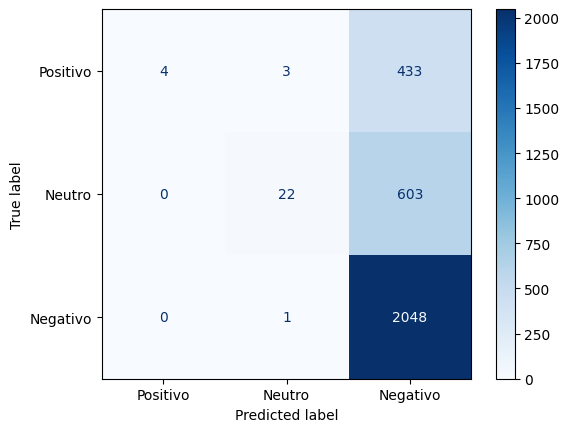

In [14]:
# =======================================================================================================
# EVALUACIÓN
# =======================================================================================================

# classification_report — da tres métricas por cada clase:
# Precision: de los que predije como positivos, ¿cuántos lo eran realmente?
# Recall: de los que eran realmente positivos, ¿cuántos detecté?
# F1-score: media armónica de las dos anteriores. Es la métrica en la que fijarse cuando hay desbalance.

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluation(y_test, y_pred, target_names = ["Positivo", "Neutro", "Negativo"]):
    report_dict = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)

    conf_matrix = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(conf_matrix, display_labels=target_names)

    print(classification_report(y_test, y_pred, target_names=target_names))
    disp.plot(cmap = "Blues")
    plt.show()

    return report_dict

report = evaluation(y_test, results)


El modelo no llega a detectar la gran mayoría de las clases positiva y neutra, aunque no clasifica incorrectamente como tales en exceso (para positiva no falla en una, simplemente no detecta los suficientes). para la clase negativa es lo contrario: clasifica mal a favor de la clase negativa pero llega a detectar todos los comentarios negativos.

La buena media macro en precision se debe a que se ponderan de igual forma los tres grupos (motivo también de la mala media macro en recall). En la media weighted vemos el resentimiento en precision, aunque para recall, precisamente porque la clase negativa tiene mayor ponderación, la media es más alta. 

Lo que indican estas medidas es un claro desbalance hacia la clase negativa, que es además la minoritaria, de ahí la gran diferencia de medias.

              precision    recall  f1-score   support

    Positivo       0.64      0.37      0.47       440
      Neutro       0.63      0.31      0.41       625
    Negativo       0.77      0.96      0.86      2049

    accuracy                           0.75      3114
   macro avg       0.68      0.55      0.58      3114
weighted avg       0.73      0.75      0.71      3114



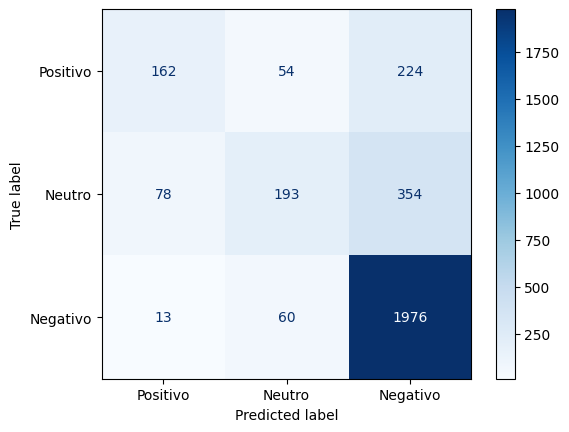

In [17]:
# =======================================================================================================
# ALTERNATIVA A MultinomialNB
# =======================================================================================================

# Puesto que multinomial no soporta class_weight, vamos a usar ComplementNB, función especialmente diseñada para datasets desbalanceados
# Además, vamos a modificar la probabilidad prior como en el proyecto anterior

from sklearn.naive_bayes import ComplementNB

c_clf = ComplementNB(class_prior=[1/3, 1/3, 1/3])

c_results, c_accuracy = train_and_evaluate(c_clf, X_train, X_test, y_train, y_test)
c_report = evaluation(y_test, c_results)


ComplementNB mejora significativamente el macro F1 respecto a MultinomialNB (0.58 vs 0.29) pero tiene el mismo problema estructural: sin class_weight el recall de positivo y neutro sigue siendo bajo porque el modelo sigue tendiendo hacia la clase mayoritaria.

La conclusión natural del proyecto es esta: Naive Bayes tiene un techo claro con datos desbalanceados, y ese techo lo has medido empíricamente comparando cuatro modelos.

              precision    recall  f1-score   support

    Positivo       0.47      0.57      0.52       440
      Neutro       0.52      0.65      0.58       625
    Negativo       0.92      0.81      0.86      2049

    accuracy                           0.74      3114
   macro avg       0.64      0.68      0.65      3114
weighted avg       0.78      0.74      0.75      3114



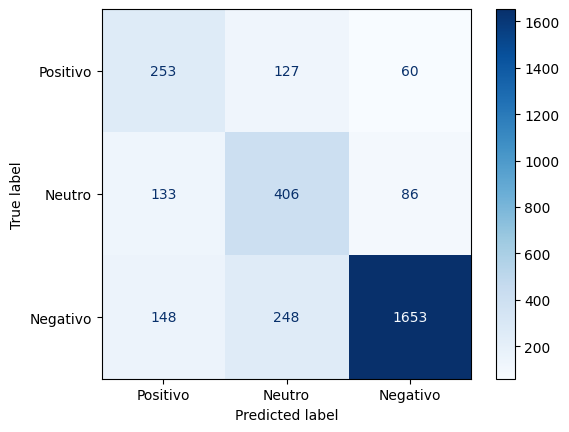

In [5]:
# =======================================================================================================
# DESBALANCE DE CLASES
# =======================================================================================================

# El objetivo es corregir la inclinación del modelo hacia la clase negativa
# MultinomialNB no soporta class_weight (le dice al modelo que penalice más los errores en clases minoritarias durante el entrenamiento)
# SMOTE de imbalanced-learn — en lugar de penalizar, genera ejemplos sintéticos de las clases minoritarias hasta equilibrar el dataset. Es más potente pero también más lento y puede introducir ruido

# Logistic regression
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(class_weight="balanced")

log_results, log_accuracy = train_and_evaluate(log_clf, X_train, X_test, y_train, y_test)
log_report = evaluation(y_test, log_results)


Mejora significativa respecto a Naive Bayes. El modelo pasa de colapsar hacia la clase negativa a distribuir las predicciones de forma razonable entre las tres clases. El macro F1 sube de 0.29 a 0.65, lo que confirma que el desbalance era el problema principal.

El trade-off es que la precision de positivo y neutro baja (0.47 y 0.52), porque al forzar al modelo a predecir más estas clases también comete más falsos positivos en ellas. Es el efecto esperado de class_weight='balanced' y se puede afinar en la optimización de hiperparámetros asignando pesos personalizados por clase.

La clase negativa sigue siendo la mejor clasificada (F1 0.86) por su mayor representación en los datos, pero ya no domina el modelo de forma patológica.

              precision    recall  f1-score   support

    Positivo       0.52      0.48      0.50       440
      Neutro       0.56      0.54      0.55       625
    Negativo       0.87      0.89      0.88      2049

    accuracy                           0.76      3114
   macro avg       0.65      0.64      0.64      3114
weighted avg       0.76      0.76      0.76      3114



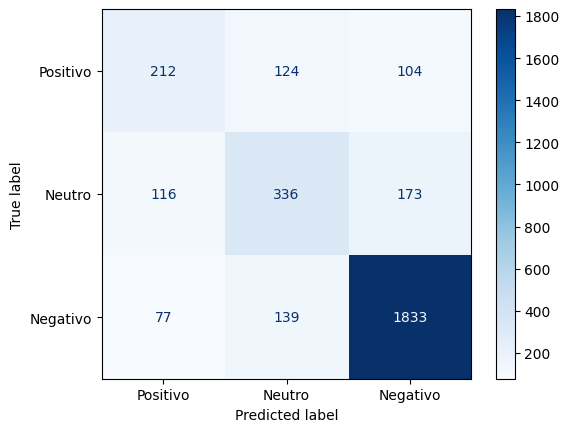

In [6]:
# Regresión lineal
from sklearn.svm import LinearSVC

lin_clf = LinearSVC(class_weight="balanced")

lin_results, lin_accuracy = train_and_evaluate(lin_clf, X_train, X_test, y_train, y_test)
lin_report = evaluation(y_test, lin_results)

El macro F1 es prácticamente igual: 0.65 en LogisticRegression vs 0.64 en LinearSVC. La diferencia real es que LinearSVC tiene más equilibrio entre precision y recall (los valores están más cerca entre sí), mientras que LogisticRegression tenía más recall que precision en positivo y neutro.

Lo que sí es peor en LinearSVC es el recall de positivo (0.48 vs 0.57), lo que significa que detecta menos comentarios positivos reales. Eso explica la ligera diferencia en macro F1.

En la práctica ambos modelos están al mismo nivel con la configuración actual. La decisión entre uno y otro la tomará el Paso 7, donde GridSearch optimizará los hiperparámetros de cada uno y verás cuál tiene más margen de mejora. 

              precision    recall  f1-score   support

    Positivo       0.88      0.08      0.15       440
      Neutro       0.64      0.38      0.47       625
    Negativo       0.73      0.97      0.83      2049

    accuracy                           0.72      3114
   macro avg       0.75      0.47      0.48      3114
weighted avg       0.73      0.72      0.66      3114



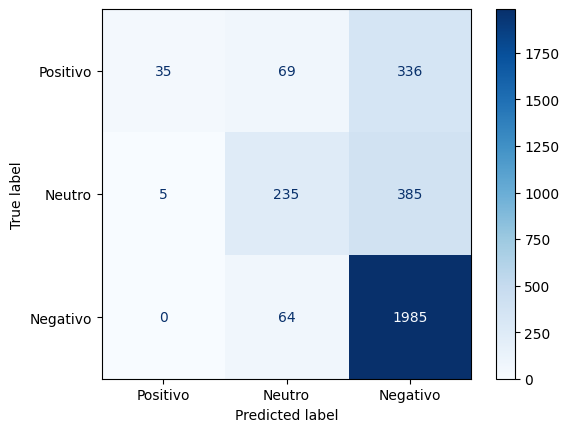

In [7]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(class_weight="balanced")

rf_results, rf_accuracy = train_and_evaluate(rf_clf, X_train, X_test, y_train, y_test)
rf_report = evaluation(y_test, rf_results)

Confirma lo que anticipábamos. El macro F1 de 0.49 es significativamente peor que LogisticRegression y LinearSVC (0.65 y 0.64). El problema es exactamente el que mencioné: los vectores TF-IDF son muy sparse y los árboles no lo manejan bien. El recall de positivo (0.09) es casi tan malo como Naive Bayes sin balanceo. Lo descartamos.

El candidato principal para el Paso 7 es LogisticRegression, con LinearSVC como alternativa cercana.

Modelo inicial

            precision    recall  f1-score   support

Positivo       0.47      0.57      0.52       440
Neutro         0.52      0.65      0.58       625
Negativo       0.92      0.81      0.86      2049

accuracy                           0.74      3114
macro avg      0.64      0.68      0.65      3114
weighted avg   0.78      0.74      0.75      3114


Para {'positive': 2, 'neutral': 5, 'negative': 6.5}

            precision    recall  f1-score   support

Positivo        0.53      0.51      0.52       440
Neutro          0.56      0.59      0.58       625
Negativo        0.88      0.88      0.88      2049

accuracy                            0.77      3114
macro avg       0.66      0.66      0.66      3114
weighted avg    0.77      0.77      0.77      3114


Para {'positive': 2, 'neutral': 5, 'negative': 6.5} y C = 0.5

            precision    recall  f1-score   support

Positivo       0.52      0.52      0.52       440
Neutro         0.56      0.61      0.58       625
Negativo       0.89      0.87      0.88      2049

accuracy                           0.77      3114
macro avg      0.66      0.67      0.66      3114
weighted avg   0.77      0.77      0.77      3114


Para {'positive': 3, 'neutral': 5, 'negative': 5.5} y C = 0.5

             precision    recall  f1-score   support

Positivo       0.59      0.45      0.51       440
Neutro         0.60      0.57      0.59       625
Negativo       0.86      0.92      0.89      2049

accuracy                           0.78      3114
macro avg      0.69      0.65      0.66      3114
weighted avg   0.77      0.78      0.77      3114


Los resultados son prácticamente idénticos a la regresión logística manual (macro F1 0.66 vs 0.65). Lo que esto significa es que el modelo ya estaba cerca de su techo con la configuración que tenías, y GridSearch lo ha confirmado. No es una mierda, es información: no hay combinación mágica de hiperparámetros que resuelva el problema.

El techo real no está en los hiperparámetros sino en la representación del texto. TF-IDF trata las palabras como independientes y sin contexto semántico. "Not good" y "good" comparten la palabra "good". Para romper ese techo hay que cambiar cómo se representa el texto.